# MNIST evaluation notebook (SNN vs MC Dropout vs EDL)

Thin notebook wrapper around `snn_eval.run_mnist`. Every training / inference / metrics / plotting step below calls `run_mnist.compute()` and `run_mnist.display()` directly — nothing here re-implements that logic, so any fix made in `run_mnist.py` is picked up automatically next time this notebook runs.

Section 2 shows the one extension point (`compute(args, loader=..., exp_name=...)`) that lets this same pipeline run against another MNIST-shaped dataset without touching training/inference/metrics code.

In [1]:
!git clone https://github.com/Ouatt-Isma/Subjective-Neural-Network-Framework.git
%cd Subjective-Neural-Network-Framework
!pip install -q -r requirements.txt

fatal: destination path 'Subjective-Neural-Network-Framework' already exists and is not an empty directory.
/content/Subjective-Neural-Network-Framework


In [2]:
!cat requirements.txt

# ── CUDA wheels (CUDA 12.1) ────────────────────────────────────────────────
# Install with:
#   pip install -r requirements.txt --extra-index-url https://download.pytorch.org/whl/cu121
# For CUDA 12.4 replace cu121 with cu124; for CPU-only drop the flag entirely.
--extra-index-url https://download.pytorch.org/whl/cu121

# ── Core ───────────────────────────────────────────────────────────────────
torch>=2.3.0
torchvision>=0.18.0
numpy>=1.23
scipy>=1.9
tqdm>=4.65

# ── Optional: frozen-backbone experiments ─────────────────────────────────
# timm>=0.9          # timm backbone (run_exp1 --backbone <timm-model>)
# matplotlib>=3.7    # rotation-sweep plots (run_mnist --plot)


In [3]:
%matplotlib inline
import argparse
import pandas as pd
from snn_eval import run_mnist, cache

In [4]:
def run_cached(exp_name, args, loader=None):
    """Thin caching wrapper around run_mnist.compute(), mirroring run_mnist.main().

    Avoids retraining / re-running inference on every notebook re-run: results
    are keyed by all params (like the CLI's results cache) and models by the
    train-only subset (like the CLI's model cache, handled inside compute()
    itself). Delete results/cache or results/models to force a clean re-run.
    """
    params = {k: v for k, v in vars(args).items() if k not in ("device", "no_cache")}
    res = None if args.no_cache else cache.load_results(exp_name, params)
    if res is None:
        res = run_mnist.compute(args, loader=loader, exp_name=exp_name)
        cache.save_results(exp_name, params, res)
    return res

## 1. MNIST (default loader)

`build_argparser()` is the exact same parser `run_mnist.py` uses from the CLI, so `parse_args([])` gives a `Namespace` of CLI defaults — tweak individual fields below instead of re-typing them.

In [47]:
args = run_mnist.build_argparser().parse_args([])  # identical defaults to the CLI
args.arch = "resnet"  # "mlp" | "cnn" | "resnet"
args.device  = "cuda"     # you're on Colab — use the GPU instead of "cpu"
args.epochs  = 15
args.Np      = 50
args.Nm      = 50
args.beta_max = 2
args.device = "cuda"
QUICK = False  # flip to False for the full paper-grade run
if QUICK:
    args.epochs, args.Np, args.Nm, args.T = 2, 3, 3, 20
    args.rot_step, args.rot_n = 45, 200

vars(args)

{'arch': 'resnet',
 'synthetic': False,
 'device': 'cuda',
 'epochs': 15,
 'd_hidden': 256,
 'beta_max': 2,
 'Np': 50,
 'Nm': 50,
 'T': 100,
 'rot_step': 15,
 'rot_n': 1000,
 'seed': 0,
 'n_train': 60000,
 'label_noise': 0.0,
 'no_cache': False}

In [48]:
res = run_cached("run_mnist", args)

[results] hit  ← results/cache/run_mnist_cb4b96de31f3_results.json



arch=resnet

Model                 Acc    NLL    ECE OOD-AUROC
MC Dropout          0.991  0.028  0.003     0.975
MCD (mean, H)       0.991  0.028  0.003     0.976
MCD (u* BALD)       0.991  0.028  0.003     0.413
EDL                 0.975  0.140  0.065     0.949
SNN (mean, H)       0.996  0.017  0.003     0.973
SNN (u* counts)     0.996  0.017  0.003     0.714
SNN (aug P soft)    0.996  0.053  0.036     0.325

Rotation sweep (means over 1000 digits)
  deg |   acc  SNN u*  SNN u_e SNN u_a SNN H  | MCD H  MCD epi MCD ale | MCD u* MCD u_e MCD u_a | EDL u  EDL H 
    0 | 0.995  0.005   0.0004  0.003   0.147  | 0.022  0.0009  0.009   | 0.134  0.0025  0.019   | 0.113  0.466 
   15 | 0.970  0.009   0.0009  0.009   0.168  | 0.055  0.0019  0.024   | 0.128  0.0054  0.050   | 0.197  0.664 
   30 | 0.850  0.033   0.0047  0.044   0.289  | 0.221  0.0078  0.097   | 0.120  0.0194  0.201   | 0.446  1.210 
   45 | 0.553  0.063   0.0101  0.090   0.441  | 0.371  0.0138  0.162   | 0.114  0.0336  0.337   |

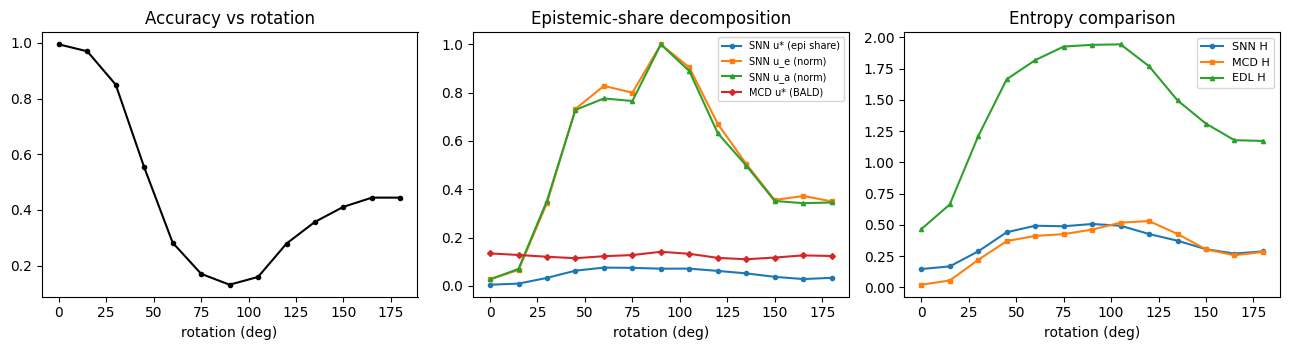

In [49]:
fig = run_mnist.display(res)  # prints tables + sweep, saves results/rotation_sweep.{csv,png}, shows inline

In [50]:
pd.DataFrame(res["table"])

,name,acc,nll,ece,ood_auroc
0,MC Dropout,0.9913,0.028405,0.003317,0.974904
1,"MCD (mean, H)",0.9913,0.028405,0.003317,0.976291
2,MCD (u* BALD),0.9913,0.028405,0.003317,0.413289
3,EDL,0.9753,0.139936,0.064822,0.949410
4,"SNN (mean, H)",0.9955,0.017332,0.002533,0.973444
5,SNN (u* counts),0.9955,0.017332,0.002533,0.714376
6,SNN (aug P soft),0.9955,0.052566,0.036495,0.325056


## 2. Adapting to another dataset

`compute()` accepts a `loader` — any zero-arg callable returning `((Xtr, ytr), (Xte, yte), Xood)` with images shaped `(N, 1, 28, 28)` and integer labels, exactly like `run_mnist.load_mnist`. Pass a different one and the rest of the pipeline (model build, training, nested sampling, MC Dropout, EDL, metrics, rotation sweep, plotting) is untouched — `compute()` now infers `K` from the labels rather than hardcoding 10.

Use a distinct `exp_name` so the alternate run's model/result cache doesn't collide with the MNIST one, and a distinct `out_prefix` in `display()` so the CSV/PNG don't overwrite `rotation_sweep.*`.

**Scope caveat:** the CNN/ResNet backbones in `models.py` (`_CNNBackbone`, `_TinyResNet`) are hardcoded for single-channel 28×28 input, so this loader-swap trick is only valid for other MNIST-shaped datasets (FashionMNIST, KMNIST, EMNIST, ...). For a genuinely different shape/channel-count/class-count (e.g. CIFAR-10), use the repo's other evaluation-ladder rungs instead — `run_exp1.py` (frozen DINOv2/CLIP backbone) or `train_fullnet.py` (full ResNet18/WRN-28-10) — rather than forcing this MNIST pipeline.

In [51]:
def load_fashion_as_id(root="./data", ntr=60000, nte=10000):
    """Same return contract as run_mnist.load_mnist, but FashionMNIST is ID and
    MNIST is OOD (roles swapped). Swap the dataset names for KMNIST/EMNIST etc.
    """
    import torch
    import torchvision as tv, torchvision.transforms as T
    tf = T.ToTensor()
    tr  = tv.datasets.FashionMNIST(root, train=True,  download=True, transform=tf)
    te  = tv.datasets.FashionMNIST(root, train=False, download=True, transform=tf)
    ood = tv.datasets.MNIST(root, train=False, download=True, transform=tf)
    def imgs(ds, n):
        X = torch.stack([ds[i][0] for i in range(min(n, len(ds)))])
        y = torch.tensor([ds[i][1] for i in range(min(n, len(ds)))])
        return X, y
    return imgs(tr, ntr), imgs(te, nte), imgs(ood, nte)[0]

arch=resnet  train=60000  test=10000  hidden=256

[training SNN]


Epoch 1/15: 100%|██████████| 937/937 [00:14<00:00, 62.85it/s]


  ep   1/15 loss=0.5025 tr_acc=0.8192 te_acc=0.8662 kl=23.7 beta=1.33 std(E[p])=0.0069


Epoch 2/15: 100%|██████████| 937/937 [00:14<00:00, 63.42it/s]


  ep   2/15 loss=0.3010 tr_acc=0.8916 te_acc=0.8850 kl=23.2 beta=2.00 std(E[p])=0.0075


...

  120°  acc=0.097  SNN u*=0.100 u_e=0.0201  MCD u*=0.077 u_e=0.0755  H=0.651


  135°  acc=0.160  SNN u*=0.119 u_e=0.0222  MCD u*=0.087 u_e=0.0640  H=0.733


  150°  acc=0.188  SNN u*=0.117 u_e=0.0225  MCD u*=0.081 u_e=0.0627  H=0.741


  165°  acc=0.255  SNN u*=0.114 u_e=0.0192  MCD u*=0.076 u_e=0.0549  H=0.699


  180°  acc=0.258  SNN u*=0.093 u_e=0.0159  MCD u*=0.090 u_e=0.0525  H=0.594
[results] saved → results/cache/fashion_mnist_1422f99b8cf1_results.json

arch=resnet

Model                 Acc    NLL    ECE OOD-AUROC
MC Dropout          0.927  0.227  0.026     0.733
MCD (mean, H)       0.927  0.227  0.026     0.745
MCD (u* BALD)       0.927  0.227  0.026     0.628
EDL                 0.905  0.571  0.178     0.601
SNN (mean, H)       0.932  0.222  0.030     0.799
SNN (u* counts)     0.932  0.222  0.030     0.477
SNN (aug P soft)    0.932  0.236  0.028     0.564

Rotation sweep (means over 1000 digits)
  deg |   acc  SNN u*  SNN u_e SNN u_a SNN H  | MCD H  MCD epi MCD ale | MCD u* MCD u_e MCD u_a | EDL u  EDL H 
    0 | 0.934  0.013   0.0016  0.013   0.188  | 0.133  0.0021  0.067   | 0.093  0.0061  0.127   | 0.311  0.967 
   15 | 0.776  0.047   0.0068  0.058   0.355  | 0.518  0.0095  0.242   | 0.074  0.0252  0.493   | 0.636  1.682 
   30 | 0.410  0.098   0.0156  0.133   0.613  | 1.017  0.020

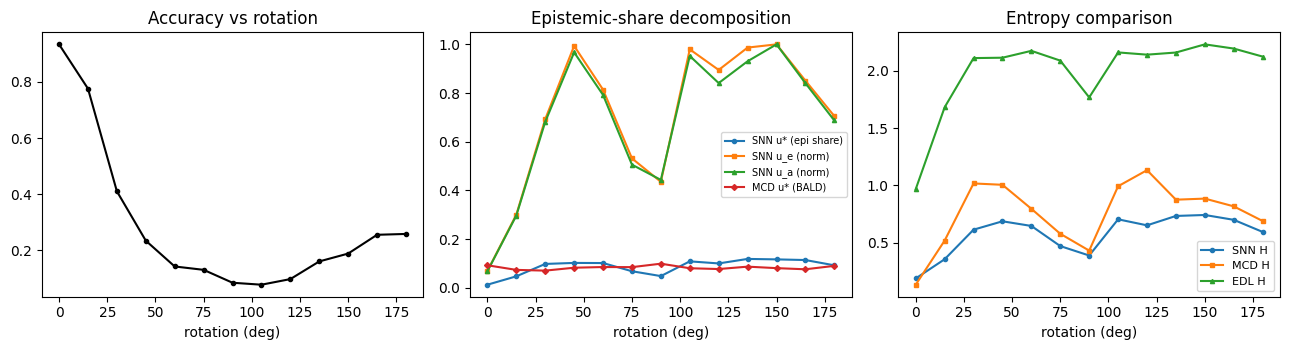

In [52]:
args_fashion = argparse.Namespace(**vars(args))  # same knobs, incl. QUICK tweaks

res_fashion = run_cached("fashion_mnist", args_fashion, loader=load_fashion_as_id)
fig_fashion = run_mnist.display(res_fashion, out_prefix="fashion_rotation_sweep")

## 3. Compare datasets side by side

Both `res` dicts came from the same `compute()`, so the table rows line up directly — no metric recomputation here, just reshaping already-computed numbers.

In [53]:
t1 = pd.DataFrame(res["table"]).assign(dataset="MNIST")
t2 = pd.DataFrame(res_fashion["table"]).assign(dataset="FashionMNIST(ID)/MNIST(OOD)")
pd.concat([t1, t2]).set_index(["dataset", "name"])

acc       nll       ece  \
dataset                     name                                           
MNIST                       MC Dropout        0.9913  0.028405  0.003317   
                            MCD (mean, H)     0.9913  0.028405  0.003317   
                            MCD (u* BALD)     0.9913  0.028405  0.003317   
                            EDL               0.9753  0.139936  0.064822   
                            SNN (mean, H)     0.9955  0.017332  0.002533   
                            SNN (u* counts)   0.9955  0.017332  0.002533   
                            SNN (aug P soft)  0.9955  0.052566  0.036495   
FashionMNIST(ID)/MNIST(OOD) MC Dropout        0.9268  0.227088  0.025570   
                            MCD (mean, H)     0.9268  0.227088  0.025570   
                            MCD (u* BALD)     0.9268  0.227088  0.025570   
                            EDL               0.9054  0.571380  0.177994   
                            SNN (mean, H)     0.9324  0.222036  0.030168   
                            SNN (u* counts)   0.9324  0.222036  0.030168   
                            SNN (aug P soft)  0.9324  0.236459  0.027839   

                                              ood_auroc  
dataset                     name                         
MNIST                       MC Dropout         0.974904  
                            MCD (mean, H)      0.976291  
                            MCD (u* BALD)      0.413289  
                            EDL                0.949410  
                            SNN (mean, H)      0.973444  
                            SNN (u* counts)    0.714376  
                            SNN (aug P soft)   0.325056  
FashionMNIST(ID)/MNIST(OOD) MC Dropout         0.733003  
                            MCD (mean, H)      0.745486  
                            MCD (u* BALD)      0.627638  
                            EDL                0.601375  
                            SNN (mean, H)      0.798899  
                            SNN (u* counts)    0.476556  
                            SNN (aug P soft)   0.564097

## 4. Epistemic probe — data scarcity (n_train sweep)

Train SNN / MC Dropout / EDL on progressively smaller fractions of MNIST (100 → 60 k samples).
With less data the trust parameters have fewer gradient steps to converge → they stay in the diffuse `epistemic_flat` / `epistemic_u` regime → different outer trust draws make **different** predictions → MI (u_e) rises.

Expected:  **`snn_u_e` (MI) ↑** as `n_train` ↓; `u_a` (eH) stays relatively low (not a noise problem).
The `n_train = 60000` row should match Section 1.

[results] hit  ← results/cache/epi_n100_aa2e3500b668_results.json
[results] hit  ← results/cache/epi_n500_7e950f09600f_results.json
[results] hit  ← results/cache/epi_n1000_fcf5d112d2b7_results.json
[results] hit  ← results/cache/epi_n5000_57ae01c7097d_results.json
[results] hit  ← results/cache/epi_n60000_11d7f3a9befe_results.json


,n_train,acc,snn_u_e (MI),snn_u_a (eH),snn_u*,mcd_u_e,ood_auroc_H
0,100,0.126,0.00272,0.00407,0.0416,0.05800,0.1940
1,500,0.772,0.02051,0.08783,0.0661,0.08839,0.6765
2,1000,0.911,0.01127,0.04551,0.0369,0.05245,0.8085
3,5000,0.974,0.00236,0.00905,0.0095,0.03446,0.6795
4,60000,0.989,0.00077,0.00279,0.0027,0.00289,0.9816


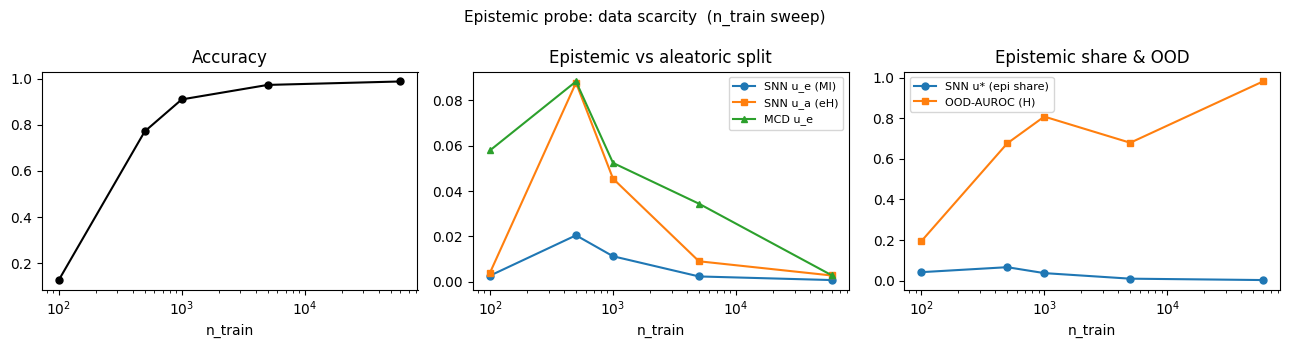

In [54]:
# Train SNN / MC Dropout / EDL on progressively smaller fractions of MNIST.
# With less data, trust parameters have fewer gradient steps to converge →
# they stay in the diffuse epistemic_flat / epistemic_u regime → different outer
# trust draws make DIFFERENT predictions → MI (u_e) rises.

n_train_levels = [100, 500, 1000, 5000, 60000]
epi_rows = []
for n in n_train_levels:
    a = run_mnist.build_argparser().parse_args([])
    a.arch, a.device, a.epochs = args.arch, args.device, args.epochs
    a.n_train, a.label_noise, a.no_cache = n, 0.0, False
    r = run_cached(f"epi_n{n}", a)
    s0  = r["sweep"][0]   # angle=0°  (in-distribution, no rotation)
    tbl = {row["name"]: row for row in r["table"]}
    epi_rows.append({
        "n_train":      n,
        "acc":          round(s0[1],  4),
        "snn_u_e (MI)": round(s0[3],  5),
        "snn_u_a (eH)": round(s0[4],  5),
        "snn_u*":       round(s0[2],  4),
        "mcd_u_e":      round(s0[10], 5),
        "ood_auroc_H":  round(tbl["SNN (mean, H)"]["ood_auroc"], 4),
    })

df_epi = pd.DataFrame(epi_rows)
display(df_epi)

try:
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
    axes[0].semilogx(df_epi["n_train"], df_epi["acc"], "k-o", ms=5)
    axes[0].set_xlabel("n_train"); axes[0].set_title("Accuracy")
    axes[1].semilogx(df_epi["n_train"], df_epi["snn_u_e (MI)"], "-o", ms=5, label="SNN u_e (MI)")
    axes[1].semilogx(df_epi["n_train"], df_epi["snn_u_a (eH)"], "-s", ms=5, label="SNN u_a (eH)")
    axes[1].semilogx(df_epi["n_train"], df_epi["mcd_u_e"],      "-^", ms=5, label="MCD u_e")
    axes[1].set_xlabel("n_train"); axes[1].set_title("Epistemic vs aleatoric split")
    axes[1].legend(fontsize=8)
    axes[2].semilogx(df_epi["n_train"], df_epi["snn_u*"],      "-o", ms=5, label="SNN u* (epi share)")
    axes[2].semilogx(df_epi["n_train"], df_epi["ood_auroc_H"], "-s", ms=5, label="OOD-AUROC (H)")
    axes[2].set_xlabel("n_train"); axes[2].set_title("Epistemic share & OOD")
    axes[2].legend(fontsize=8)
    fig.suptitle("Epistemic probe: data scarcity  (n_train sweep)", fontsize=11)
    fig.tight_layout()
    plt.savefig("results/probe_epistemic_n_train.png", dpi=140)
    plt.show()
except ImportError:
    pass


## 5. Aleatoric probe — label noise

Train on all 60 k MNIST images but randomly flip `label_noise` fraction of training labels.
The test set is always **clean** — any uncertainty on test images reflects the noisy decision boundary baked in during training.

Expected: **`u_a` (eH) ↑** as noise rises; `u_e` (MI) lower than the data-scarcity case because trust draws agree on *what* is uncertain even when they can't agree on a class (aleatoric regime: α ≈ β >> 1).

[results] hit  ← results/cache/alea_noise00_6b6ed1442a09_results.json
[results] hit  ← results/cache/alea_noise10_7677cfafb000_results.json
[results] hit  ← results/cache/alea_noise20_1ca3cc17ffe8_results.json
[results] hit  ← results/cache/alea_noise40_6edfbb43b485_results.json


,label_noise,acc,snn_u_e (MI),snn_u_a (eH),snn_u*,mcd_u_e,mcd_u_a
0,0.0,0.992,0.00060,0.00309,0.0032,0.00347,0.02210
1,0.1,0.990,0.00026,0.00079,0.0012,0.01951,0.45661
2,0.2,0.994,0.00035,0.00152,0.0019,0.02456,0.89210
3,0.4,0.988,0.00104,0.00503,0.0023,0.02489,1.41514


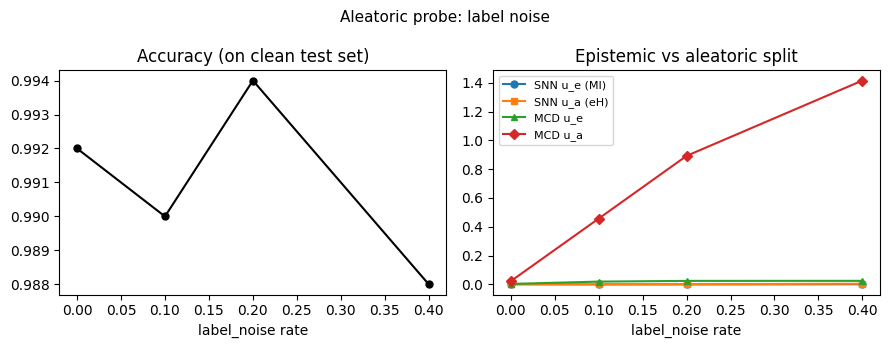

In [55]:
# Train on all 60 k MNIST images but randomly flip `label_noise` fraction of labels.
# Test set is always CLEAN — any uncertainty on test images reflects the noisy boundary
# baked in during training (pure aleatoric: same input can appear with different labels).
#
# Expected decomposition on clean test images:
#   u_a (eH) ↑  — model learns an irreducibly uncertain boundary; each trust draw is less sharp
#   u_e (MI) lower than in the data-scarcity case — trust draws AGREE on their uncertainty
#   (contrast Sec 4 where draws DISAGREE on the correct prediction → high MI)

noise_levels = [0.0, 0.1, 0.2, 0.4]
alea_rows = []
for rate in noise_levels:
    a = run_mnist.build_argparser().parse_args([])
    a.arch, a.device, a.epochs = args.arch, args.device, args.epochs
    a.n_train, a.label_noise, a.no_cache = 60000, rate, False
    r = run_cached(f"alea_noise{int(rate * 100):02d}", a)
    s0 = r["sweep"][0]   # angle=0°  (clean in-distribution)
    alea_rows.append({
        "label_noise":   rate,
        "acc":           round(s0[1],  4),
        "snn_u_e (MI)":  round(s0[3],  5),
        "snn_u_a (eH)":  round(s0[4],  5),
        "snn_u*":        round(s0[2],  4),
        "mcd_u_e":       round(s0[10], 5),
        "mcd_u_a":       round(s0[11], 5),
    })

df_alea = pd.DataFrame(alea_rows)
display(df_alea)

try:
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
    axes[0].plot(df_alea["label_noise"], df_alea["acc"], "k-o", ms=5)
    axes[0].set_xlabel("label_noise rate"); axes[0].set_title("Accuracy (on clean test set)")
    axes[1].plot(df_alea["label_noise"], df_alea["snn_u_e (MI)"],  "-o", ms=5, label="SNN u_e (MI)")
    axes[1].plot(df_alea["label_noise"], df_alea["snn_u_a (eH)"],  "-s", ms=5, label="SNN u_a (eH)")
    axes[1].plot(df_alea["label_noise"], df_alea["mcd_u_e"],       "-^", ms=5, label="MCD u_e")
    axes[1].plot(df_alea["label_noise"], df_alea["mcd_u_a"],       "-D", ms=5, label="MCD u_a")
    axes[1].set_xlabel("label_noise rate"); axes[1].set_title("Epistemic vs aleatoric split")
    axes[1].legend(fontsize=8)
    fig.suptitle("Aleatoric probe: label noise", fontsize=11)
    fig.tight_layout()
    plt.savefig("results/probe_aleatoric_label_noise.png", dpi=140)
    plt.show()
except ImportError:
    pass


## 6. Aleatoric probe — pixel noise at inference

No retraining: add Gaussian noise N(0, σ²) to clean test images and re-run inference on the baseline model.

Each trust draw sees the **same noisy image** and is individually uncertain → eH rises.
Cross-draw disagreement (MI) stays low because all trust draws face the same ambiguous input.

Expected:  **`snn_u_a` (eH) ↑** as σ grows; **`snn_u_e` (MI) stays flat**; `u* = MI/H` stays low.

[models] loaded ['edl', 'mcd', 'snn'] ← results/models/run_mnist_a99d9aa153e1/
[training skipped — models loaded from cache]


,sigma,acc,snn_u_e,snn_u_a,snn_u,mcd_u_e,mcd_u_a,edl_u
0,0.00,0.9325,0.007013,0.032163,0.023088,0.032176,0.135257,0.332043
1,0.05,0.9240,0.007712,0.032899,0.026380,0.074935,0.311601,0.339838
2,0.10,0.8890,0.009509,0.040582,0.033234,0.101554,0.418236,0.421037
3,0.20,0.3375,0.026235,0.114551,0.085358,0.017750,0.079284,0.514769
4,0.40,0.1035,0.000599,0.002208,0.003514,0.002475,0.013458,0.789463
5,0.80,0.1035,0.009021,0.030030,0.051741,0.002812,0.015218,0.655956


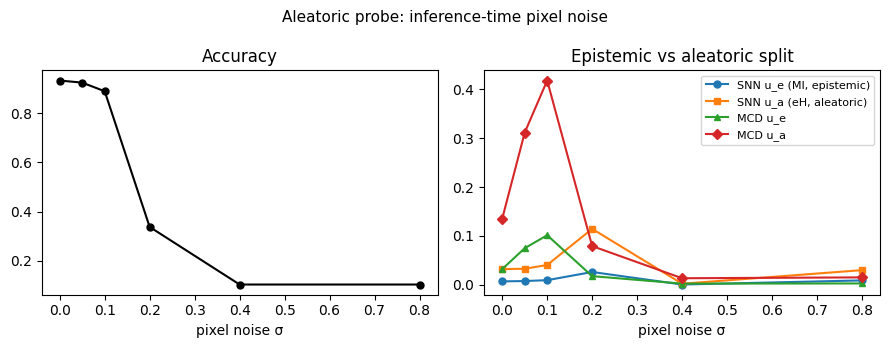

In [56]:
import torchvision as tv, torchvision.transforms as T
import torch, os

# Load baseline trained models from cache (no retraining if Section 1 already ran).
base_args = run_mnist.build_argparser().parse_args([])
base_args.arch, base_args.device, base_args.epochs = args.arch, args.device, args.epochs
base_args.n_train, base_args.label_noise = 60000, 0.0

tf = T.ToTensor()
te_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=tf)
n_probe = 2000
Xte_i = torch.stack([te_ds[i][0] for i in range(n_probe)])
yte   = torch.tensor([te_ds[i][1] for i in range(n_probe)])

tr_ds  = tv.datasets.MNIST("./data", train=True, download=True, transform=tf)
Xtr_i2 = torch.stack([tr_ds[i][0] for i in range(min(2000, len(tr_ds)))])
ytr2   = torch.tensor([tr_ds[i][1] for i in range(len(Xtr_i2))])

heads = run_mnist.build_or_train_models(
    base_args, K=10,
    Xtr=run_mnist._prep_inputs(Xtr_i2, base_args.arch), ytr=ytr2,
    Xte=run_mnist._prep_inputs(Xte_i,  base_args.arch), yte=yte,
    exp_name="run_mnist"
)

os.makedirs("results", exist_ok=True)
noise_rows = run_mnist.pixel_noise_probe(
    heads, Xte_i, yte, base_args, K=10,
    sigmas=[0.0, 0.05, 0.1, 0.2, 0.4, 0.8]
)
df_noise = pd.DataFrame(noise_rows)
display(df_noise[["sigma", "acc", "snn_u_e", "snn_u_a", "snn_u", "mcd_u_e", "mcd_u_a", "edl_u"]])

try:
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
    axes[0].plot(df_noise["sigma"], df_noise["acc"], "k-o", ms=5)
    axes[0].set_xlabel("pixel noise σ"); axes[0].set_title("Accuracy")
    axes[1].plot(df_noise["sigma"], df_noise["snn_u_e"], "-o", ms=5, label="SNN u_e (MI, epistemic)")
    axes[1].plot(df_noise["sigma"], df_noise["snn_u_a"], "-s", ms=5, label="SNN u_a (eH, aleatoric)")
    axes[1].plot(df_noise["sigma"], df_noise["mcd_u_e"], "-^", ms=5, label="MCD u_e")
    axes[1].plot(df_noise["sigma"], df_noise["mcd_u_a"], "-D", ms=5, label="MCD u_a")
    axes[1].set_xlabel("pixel noise σ"); axes[1].set_title("Epistemic vs aleatoric split")
    axes[1].legend(fontsize=8)
    fig.suptitle("Aleatoric probe: inference-time pixel noise", fontsize=11)
    fig.tight_layout()
    plt.savefig("results/probe_aleatoric_pixel_noise.png", dpi=140)
    plt.show()
except ImportError:
    pass


## 7. Epistemic probe — unseen classes (class-split OOD)

Train on digits 0–4 only; OOD = digits 5–9 the model has never seen.
This is a controlled epistemic gap: the model has the capacity but lacks training signal for those output directions, so trust parameters for unseen-class feature regions should stay diffuse → high MI (u_e).

Expected:  OOD-AUROC high for `u_e` / `u*` / `H`; `u_e >> u_a` on the unseen-class split.

[results] hit  ← results/cache/class_split_0to4_8fbc835f64aa_results.json

Class-split OOD probe  (train=digits 0–4, OOD=digits 5–9):

arch=resnet

Model                 Acc    NLL    ECE OOD-AUROC
MC Dropout          0.999  0.003  0.001     0.976
MCD (mean, H)       0.999  0.003  0.001     0.977
MCD (u* BALD)       0.999  0.003  0.001     0.122
EDL                 0.994  0.048  0.032     0.942
SNN (mean, H)       0.996  0.015  0.004     0.959
SNN (u* counts)     0.996  0.015  0.004     0.366
SNN (aug P soft)    0.996  0.107  0.091     0.191

Rotation sweep (means over 200 digits)
  deg |   acc  SNN u*  SNN u_e SNN u_a SNN H  | MCD H  MCD epi MCD ale | MCD u* MCD u_e MCD u_a | EDL u  EDL H 
    0 | 0.995  0.002   0.0001  0.000   0.366  | 0.007  0.0001  0.004   | 0.122  0.0004  0.007   | 0.040  0.184 
   90 | 0.240  0.031   0.0089  0.043   0.458  | 0.238  0.0109  0.112   | 0.109  0.0219  0.216   | 0.348  0.730 
  180 | 0.595  0.028   0.0078  0.032   0.442  | 0.316  0.0058  0.151   | 0.0

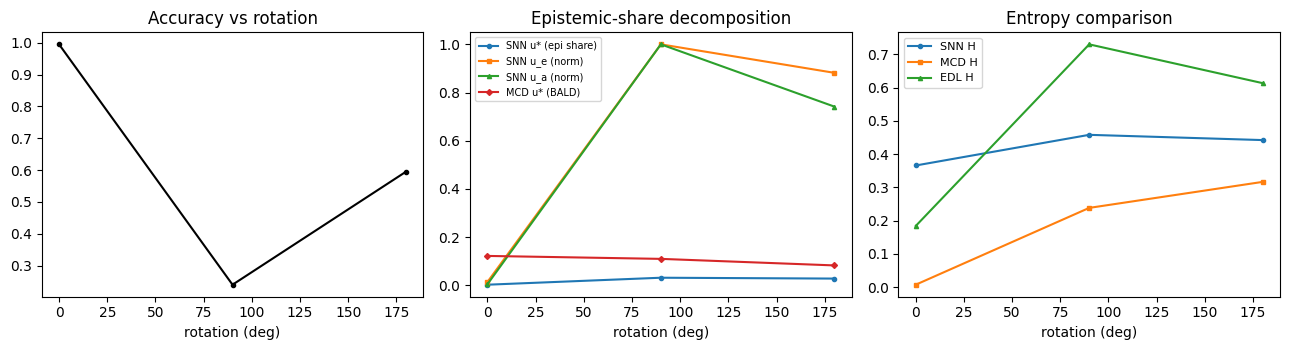

In [57]:

# Train only on digits 0–4; OOD = digits 5–9 (model has no training signal there).
# Expected: high u_e (MI) on unseen-class images — trust parameters remain diffuse
# for feature regions the model has never trained on (pure epistemic gap).

def load_split():
    return run_mnist.load_mnist_class_split(id_classes=(0, 1, 2, 3, 4), nte=1000)

a_split = run_mnist.build_argparser().parse_args([])
a_split.arch, a_split.device, a_split.epochs = args.arch, args.device, args.epochs
a_split.n_train, a_split.label_noise, a_split.no_cache = 60000, 0.0, False
a_split.rot_step, a_split.rot_n = 90, 200   # shorter rotation sweep

r_split = run_cached("class_split_0to4", a_split, loader=load_split)
print("\nClass-split OOD probe  (train=digits 0–4, OOD=digits 5–9):")
fig_split = run_mnist.display(r_split, out_prefix="class_split_rotation")
